In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sbn
from scipy import stats
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

import math

In [ ]:
sbn.set_palette("pastel")

In [ ]:
!gdown 1EFA6FA5dexDzoj110GKYOtIv_ifReLED

Downloading...
From: https://drive.google.com/uc?id=1EFA6FA5dexDzoj110GKYOtIv_ifReLED
To: /content/telecom_customer_churn.csv
100% 1.44M/1.44M [00:00<00:00, 34.3MB/s]


In [ ]:
df = pd.read_csv('/content/telecom_customer_churn.csv')
df

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.60,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.00,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.90,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.00,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.90,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,Female,20,No,0,La Mesa,91941,32.759327,-116.997260,0,...,Credit Card,55.15,742.90,0.00,0,606.84,1349.74,Stayed,NaN,NaN
7039,9992-RRAMN,Male,40,Yes,0,Riverbank,95367,37.734971,-120.954271,1,...,Bank Withdrawal,85.10,1873.70,0.00,0,356.40,2230.10,Churned,Dissatisfaction,Product dissatisfaction
7040,9992-UJOEL,Male,22,No,0,Elk,95432,39.108252,-123.645121,0,...,Credit Card,50.30,92.75,0.00,0,37.24,129.99,Joined,NaN,NaN
7041,9993-LHIEB,Male,21,Yes,0,Solana Beach,92075,33.001813,-117.263628,5,...,Credit Card,67.85,4627.65,0.00,0,142.04,4769.69,Stayed,NaN,NaN


In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head()

,customer_id,gender,age,married,number_of_dependents,city,zip_code,latitude,longitude,number_of_referrals,...,payment_method,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue,customer_status,churn_category,churn_reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_id                        7043 non-null   object 
 1   gender                             7043 non-null   object 
 2   age                                7043 non-null   int64  
 3   married                            7043 non-null   object 
 4   number_of_dependents               7043 non-null   int64  
 5   city                               7043 non-null   object 
 6   zip_code                           7043 non-null   int64  
 7   latitude                           7043 non-null   float64
 8   longitude                          7043 non-null   float64
 9   number_of_referrals                7043 non-null   int64  
 10  tenure_in_months                   7043 non-null   int64  
 11  offer                              3166 non-null   objec

In [ ]:
df = df.drop(columns=['customer_id'])

In [ ]:
df[['city','latitude','longitude']]

,city,latitude,longitude
0,Frazier Park,34.827662,-118.999073
1,Glendale,34.162515,-118.203869
2,Costa Mesa,33.645672,-117.922613
3,Martinez,38.014457,-122.115432
4,Camarillo,34.227846,-119.079903
...,...,...,...
7038,La Mesa,32.759327,-116.997260
7039,Riverbank,37.734971,-120.954271
7040,Elk,39.108252,-123.645121
7041,Solana Beach,33.001813,-117.263628


In [ ]:
color_map = {
    'Stayed': '#7590C4',
    'Churned': '#F0A58F',
    'Joined': '#90C490'
}

city_stats = df.groupby(['city', 'latitude', 'longitude', 'customer_status']).size().reset_index(name='count')

city_total = df.groupby(['city']).size().reset_index(name='total')
city_stats = city_stats.merge(city_total, on='city')
city_stats['percentage'] = (city_stats['count'] / city_stats['total'] * 100).round(2)

fig = px.scatter_mapbox(city_stats,
                        lat='latitude',
                        lon='longitude',
                        hover_name='city',
                        hover_data=['customer_status', 'count', 'percentage'],
                        color='customer_status',
                        size='count',
                        color_discrete_map=color_map,
                        zoom=5,
                        height=700,
                        title='Customer Status Distribution by City')

fig.update_layout(mapbox_style="open-street-map")
fig.show()

In [ ]:
coords = df[['latitude', 'longitude']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['region_code'] = kmeans.fit_predict(coords)

region_centers = df.groupby('region_code')[['latitude', 'longitude']].mean()
print(region_centers)

region_names = {
    0: 'Northern California',
    1: 'Southern California',
    2: 'Central California',
}

df['region'] = df['region_code'].map(region_names)

df = df.drop(['region_code'], axis=1)

              latitude   longitude
region_code                       
0            37.611400 -121.239425
1            33.912181 -117.792895
2            39.923717 -122.363924


In [ ]:
print(df['region'].value_counts())

region
Southern California    3399
Northern California    2513
Central California     1131
Name: count, dtype: int64


In [ ]:
df_sample = df.drop_duplicates(subset=['latitude', 'longitude'])

fig = px.scatter_mapbox(df_sample,
                        lat='latitude',
                        lon='longitude',
                        color='region',
                        zoom=5,
                        height=700,
                        title='3 Geographic Regions')

fig.update_layout(mapbox_style="open-street-map")
fig.show()

Missing values

In [ ]:
null = df.isnull().sum()/df.shape[0]*100
null

,0
gender,0.000000
age,0.000000
married,0.000000
number_of_dependents,0.000000
city,0.000000
zip_code,0.000000
latitude,0.000000
longitude,0.000000
number_of_referrals,0.000000
tenure_in_months,0.000000


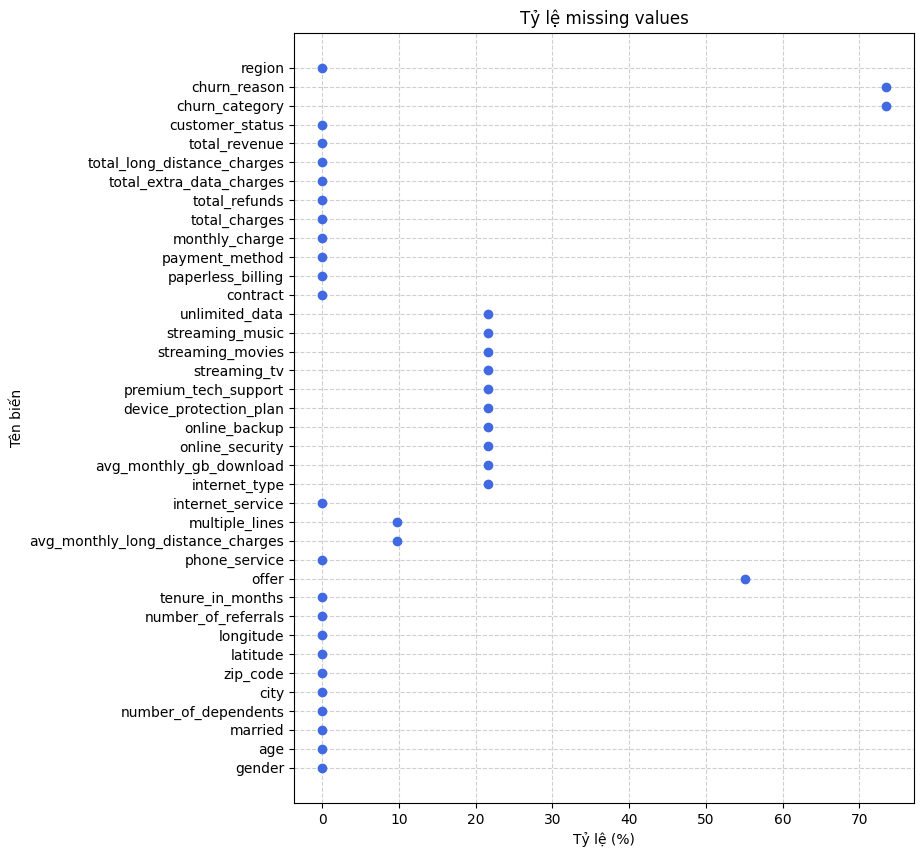

In [ ]:
plt.figure(figsize=(8,10))
plt.plot(null.values, null.index, 'o', color='royalblue')
plt.title('Tỷ lệ missing values')
plt.xlabel('Tỷ lệ (%)')
plt.ylabel('Tên biến')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

Phân loại biến

In [ ]:
numerical_cols = df.select_dtypes(include=["int","float"]).columns
categorical_cols = df.select_dtypes(include=["object","bool"]).columns

print(f'Số lượng biến định lượng: {len(numerical_cols)}\nGồm các biến: ', numerical_cols)
print(f'\nSố lượng biến định tính: {len(categorical_cols)}\n Gồm các biến: ', categorical_cols)

Số lượng biến định lượng: 15
Gồm các biến:  Index(['age', 'number_of_dependents', 'zip_code', 'latitude', 'longitude',
       'number_of_referrals', 'tenure_in_months',
       'avg_monthly_long_distance_charges', 'avg_monthly_gb_download',
       'monthly_charge', 'total_charges', 'total_refunds',
       'total_extra_data_charges', 'total_long_distance_charges',
       'total_revenue'],
      dtype='object')

Số lượng biến định tính: 23
 Gồm các biến:  Index(['gender', 'married', 'city', 'offer', 'phone_service', 'multiple_lines',
       'internet_service', 'internet_type', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'streaming_music', 'unlimited_data', 'contract',
       'paperless_billing', 'payment_method', 'customer_status',
       'churn_category', 'churn_reason', 'region'],
      dtype='object')


Unique

In [ ]:
df.nunique()

,0
gender,2
age,62
married,2
number_of_dependents,10
city,1106
zip_code,1626
latitude,1626
longitude,1625
number_of_referrals,12
tenure_in_months,72


Thống kê tần suất giá trị của các biến phân loại

In [ ]:
for i in df.select_dtypes(include = 'object').columns:
    print(df[i].value_counts())
    print("***"*10)

gender
Male      3555
Female    3488
Name: count, dtype: int64
******************************
married
No     3641
Yes    3402
Name: count, dtype: int64
******************************
city
Los Angeles         293
San Diego           285
San Jose            112
Sacramento          108
San Francisco       104
                   ... 
Eldridge              2
Holtville             2
Johannesburg          2
South Lake Tahoe      2
Jacumba               2
Name: count, Length: 1106, dtype: int64
******************************
offer
Offer B    824
Offer E    805
Offer D    602
Offer A    520
Offer C    415
Name: count, dtype: int64
******************************
phone_service
Yes    6361
No      682
Name: count, dtype: int64
******************************
multiple_lines
No     3390
Yes    2971
Name: count, dtype: int64
******************************
internet_service
Yes    5517
No     1526
Name: count, dtype: int64
******************************
internet_type
Fiber Optic    3035
DSL            1

EDA

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,7043.0,46.509726,16.750352,19.000000,32.000000,46.000000,60.000000,80.000000
number_of_dependents,7043.0,0.468692,0.962802,0.000000,0.000000,0.000000,0.000000,9.000000
zip_code,7043.0,93486.070567,1856.767505,90001.000000,92101.000000,93518.000000,95329.000000,96150.000000
latitude,7043.0,36.197455,2.468929,32.555828,33.990646,36.205465,38.161321,41.962127
longitude,7043.0,-119.756684,2.154425,-124.301372,-121.788090,-119.595293,-117.969795,-114.192901
number_of_referrals,7043.0,1.951867,3.001199,0.000000,0.000000,0.000000,3.000000,11.000000
tenure_in_months,7043.0,32.386767,24.542061,1.000000,9.000000,29.000000,55.000000,72.000000
avg_monthly_long_distance_charges,6361.0,25.420517,14.200374,1.010000,13.050000,25.690000,37.680000,49.990000
avg_monthly_gb_download,5517.0,26.189958,19.586585,2.000000,13.000000,21.000000,30.000000,85.000000
monthly_charge,7043.0,63.596131,31.204743,-10.000000,30.400000,70.050000,89.750000,118.750000


In [ ]:
df.describe(include='object')

,gender,married,city,offer,phone_service,multiple_lines,internet_service,internet_type,online_security,online_backup,...,streaming_movies,streaming_music,unlimited_data,contract,paperless_billing,payment_method,customer_status,churn_category,churn_reason,region
count,7043,7043,7043,3166,7043,6361,7043,5517,5517,5517,...,5517,5517,5517,7043,7043,7043,7043,1869,1869,7043
unique,2,2,1106,5,2,2,2,3,2,2,...,2,2,2,3,2,3,3,5,20,3
top,Male,No,Los Angeles,Offer B,Yes,No,Yes,Fiber Optic,No,No,...,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,Stayed,Competitor,Competitor had better devices,Southern California
freq,3555,3641,293,824,6361,3390,5517,3035,3498,3088,...,2785,3029,4745,3610,4171,3909,4720,841,313,3399


Trực quan phân phối các biến định lượng

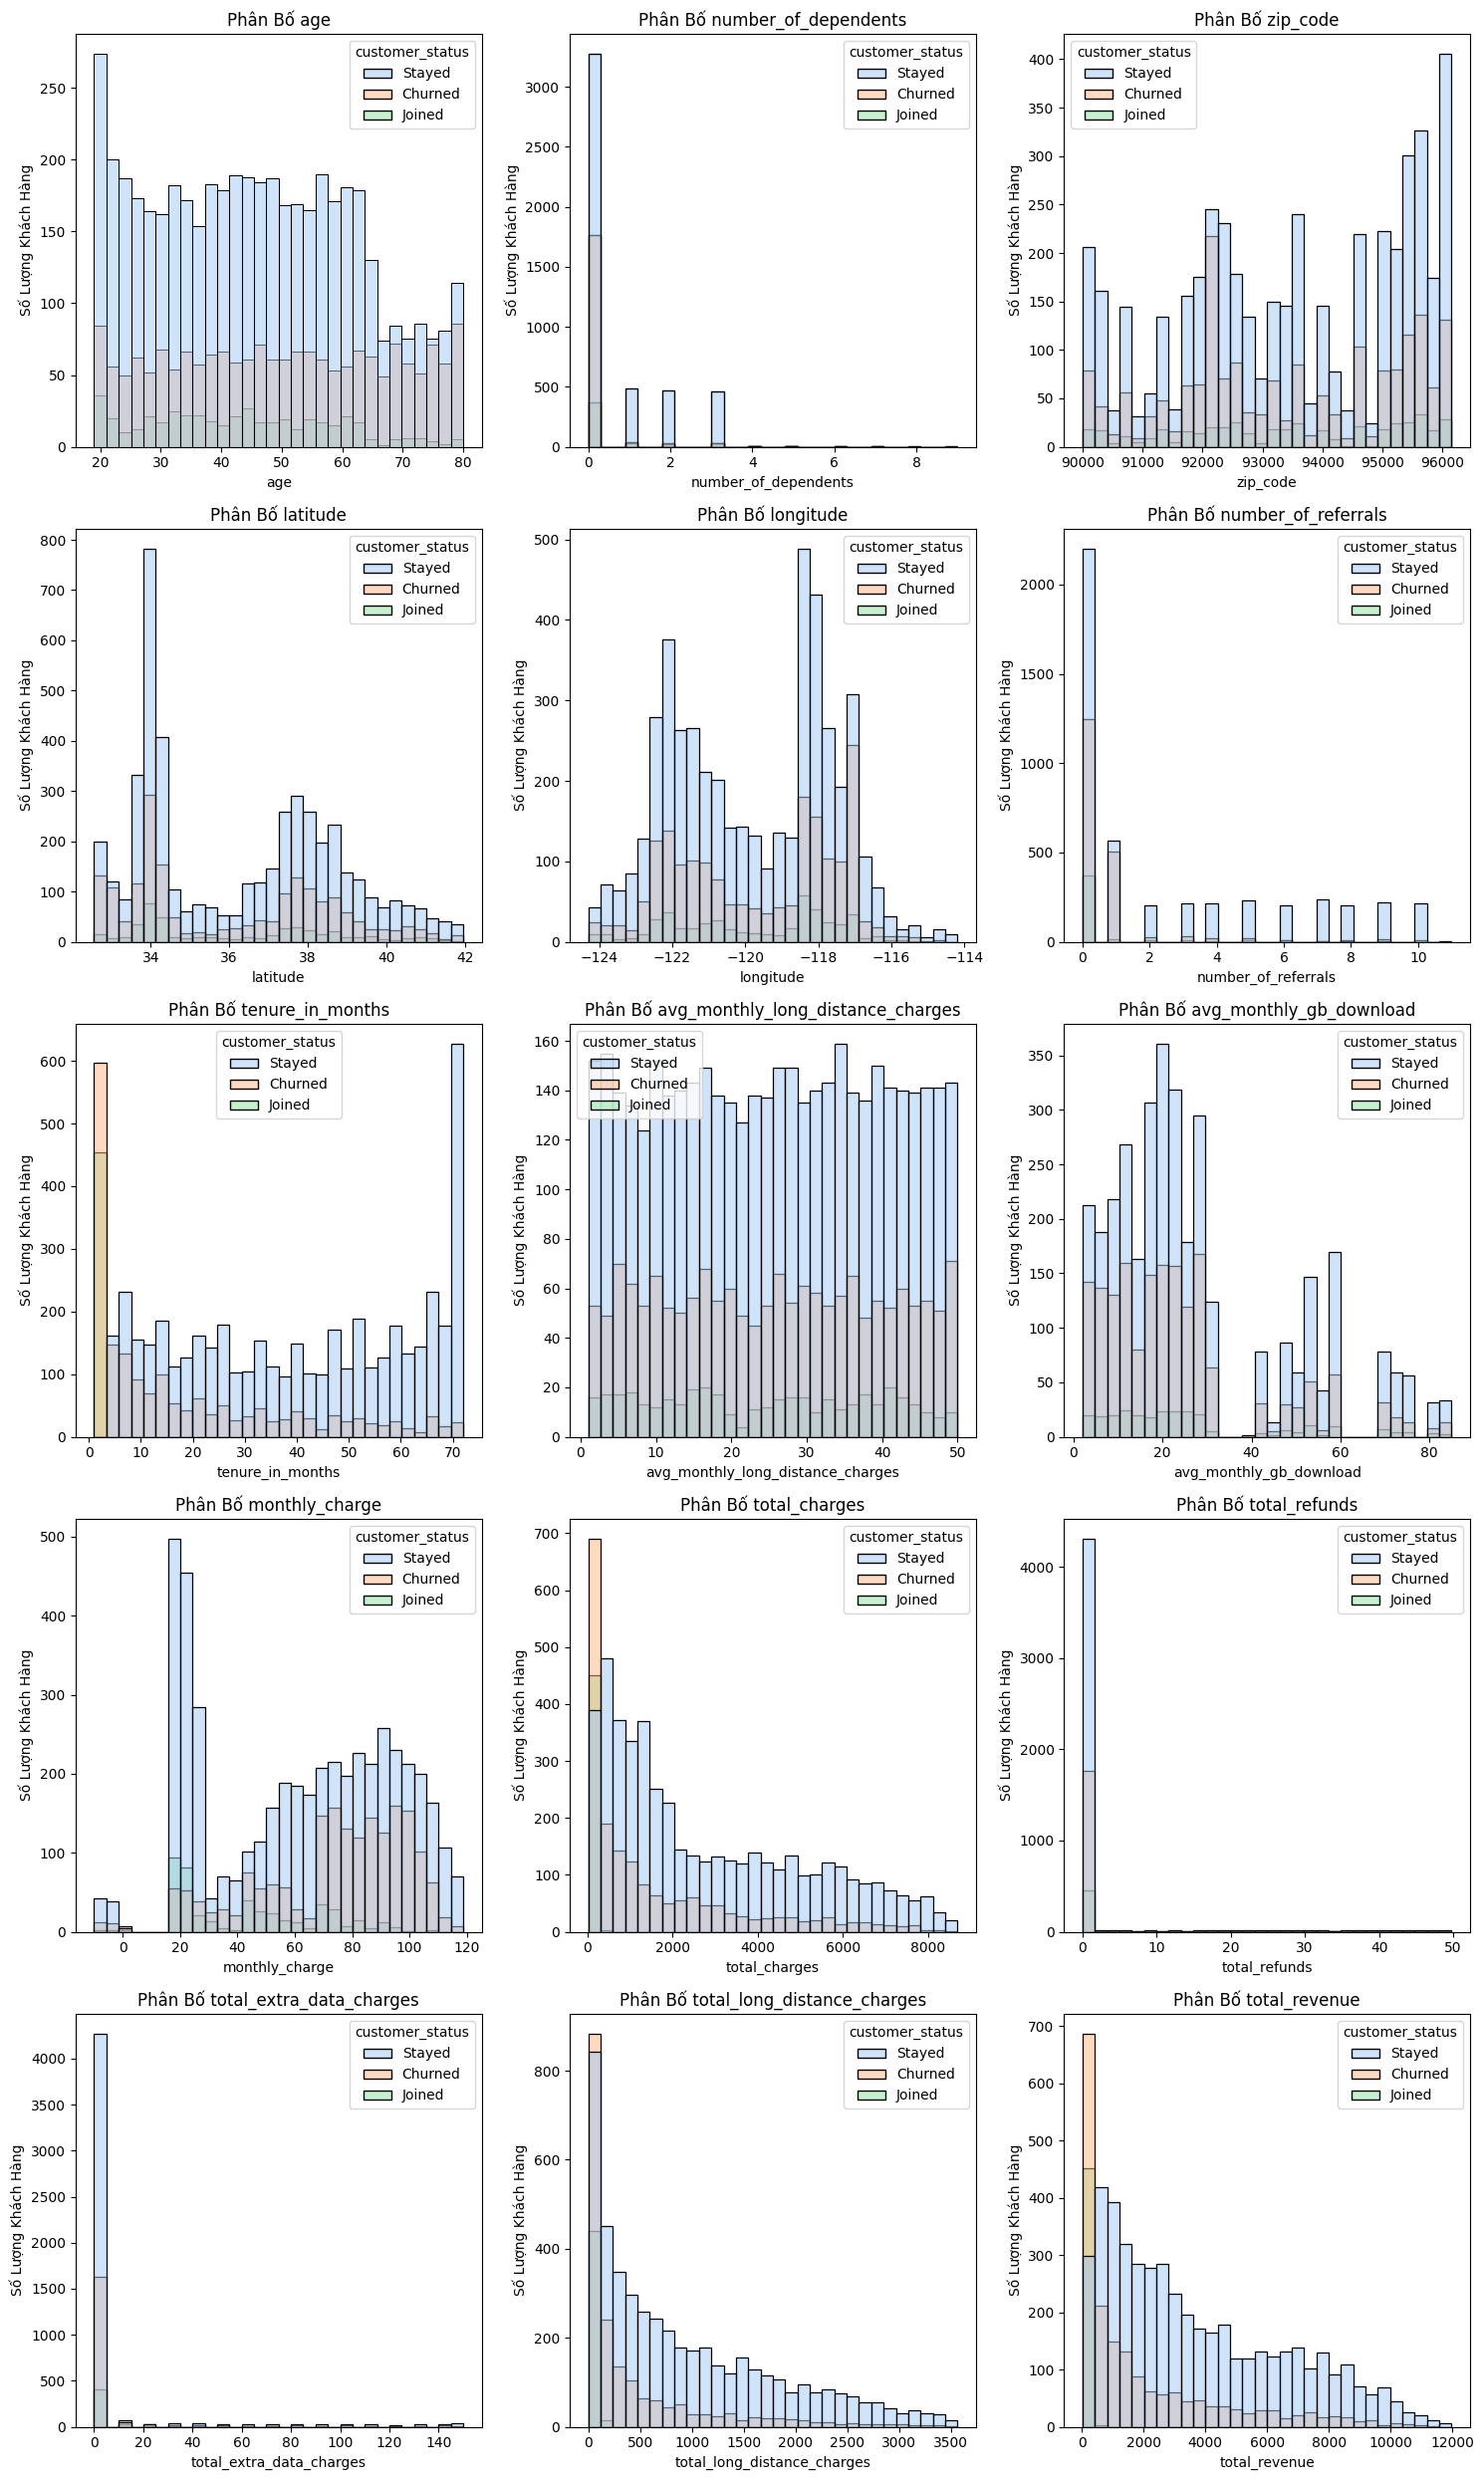

In [ ]:
n = len(numerical_cols)
rows = math.ceil(n / 3)
cols = 3


plt.figure(figsize=(15, 5*rows))
for i, col in enumerate(df[numerical_cols]):
    plt.subplot(rows, cols, i+1)
    sbn.histplot(x = df[col], hue=df['customer_status'], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Phân Bố {col}')
    plt.xlabel(col)
    plt.ylabel('Số Lượng Khách Hàng')
    plt.tight_layout()

Trực quan outliers

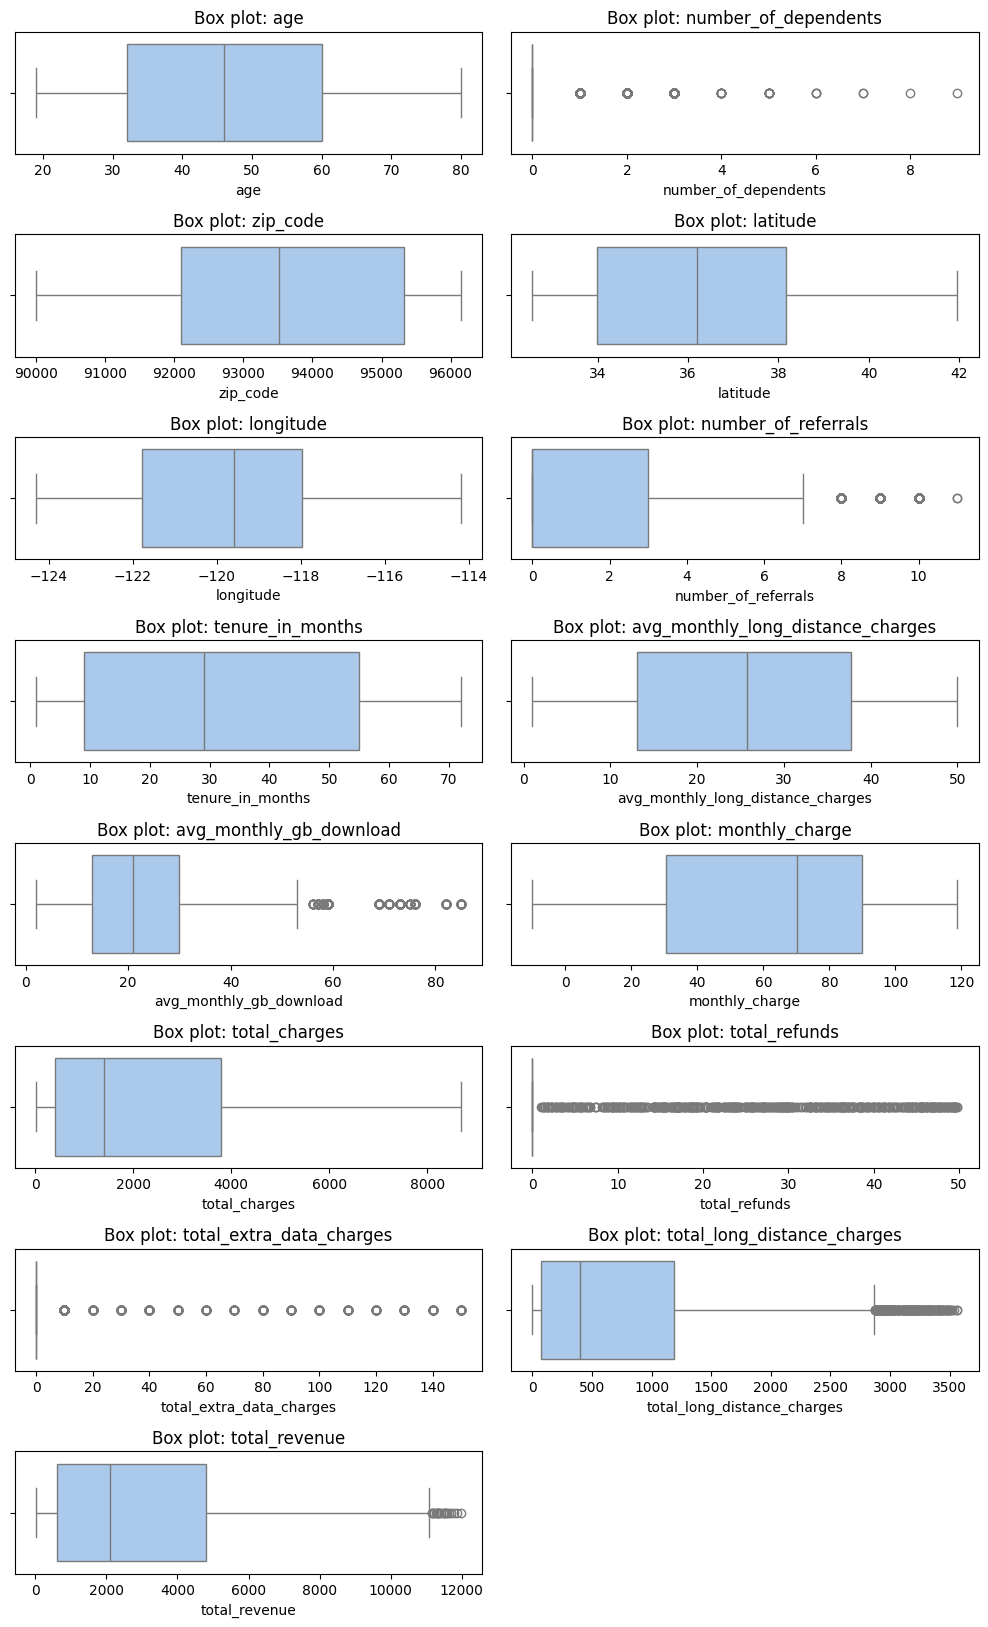

In [ ]:
plt.figure(figsize=(10,20))
for i, col in enumerate(df[numerical_cols]):
    plt.subplot(10,2,i+1)
    sbn.boxplot(df[col].dropna(), orient='h')  # bỏ qua giá trị missing
    plt.title(f'Box plot: {col}')
    plt.grid(False)
plt.tight_layout()
plt.show()

Phân tích biến định tính

In [ ]:
df.select_dtypes(include='object').columns

Index(['gender', 'married', 'city', 'offer', 'phone_service', 'multiple_lines',
       'internet_service', 'internet_type', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'streaming_music', 'unlimited_data', 'contract',
       'paperless_billing', 'payment_method', 'customer_status',
       'churn_category', 'churn_reason', 'region'],
      dtype='object')

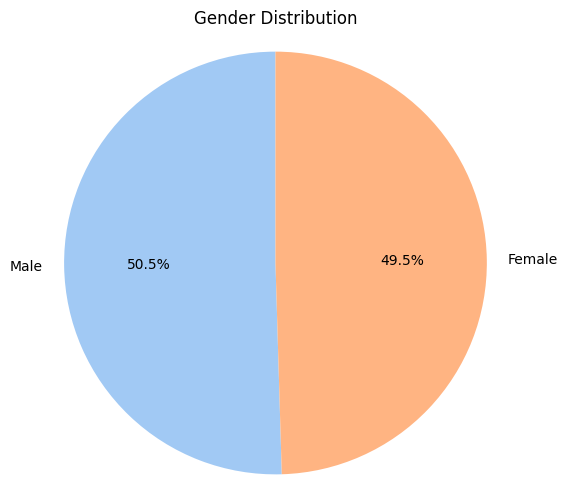

In [ ]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Gender Distribution')
plt.axis('equal')
plt.show()

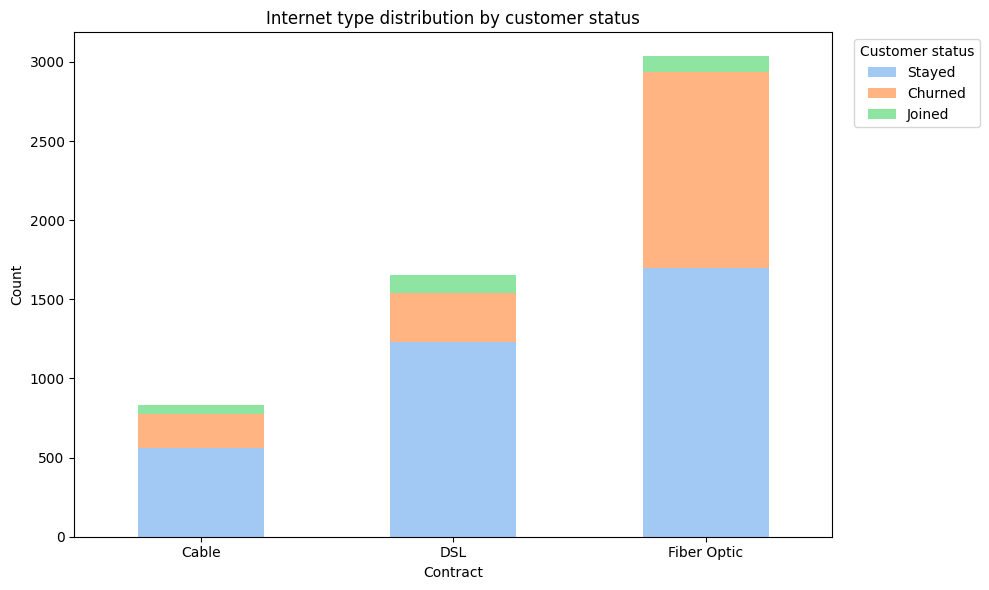

In [ ]:
ct = pd.crosstab(df['internet_type'], df['customer_status'])
desired_order = ['Stayed', 'Churned', 'Joined']
ct = ct[desired_order]

ax = ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Internet type distribution by customer status')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Customer status', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

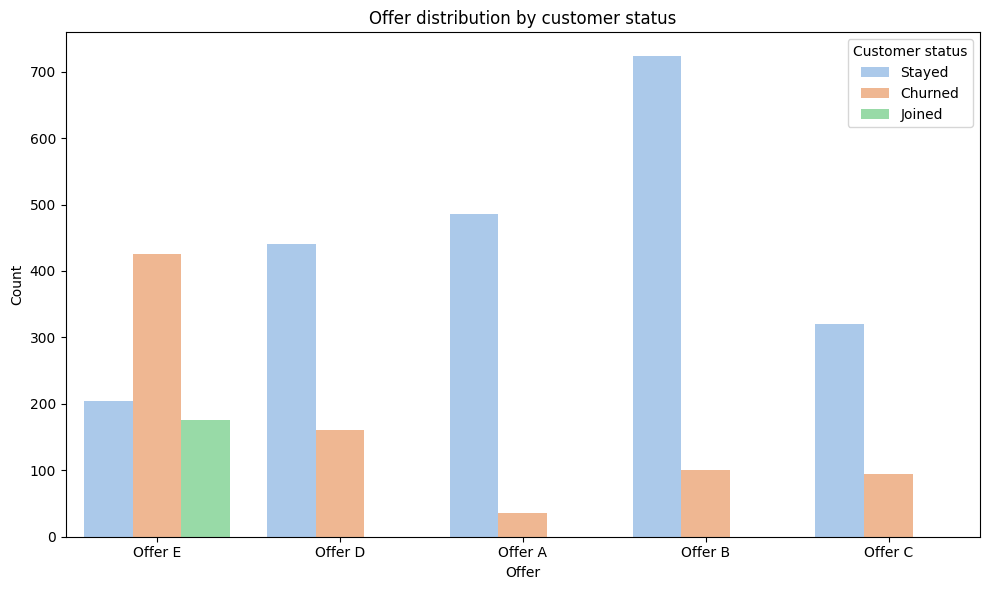

In [ ]:
plt.figure(figsize=(10,6))
sbn.countplot(
    data=df,
    x='offer',
    hue='customer_status'
)

plt.title('Offer distribution by customer status')
plt.xlabel('Offer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Customer status')
plt.tight_layout()
plt.show()


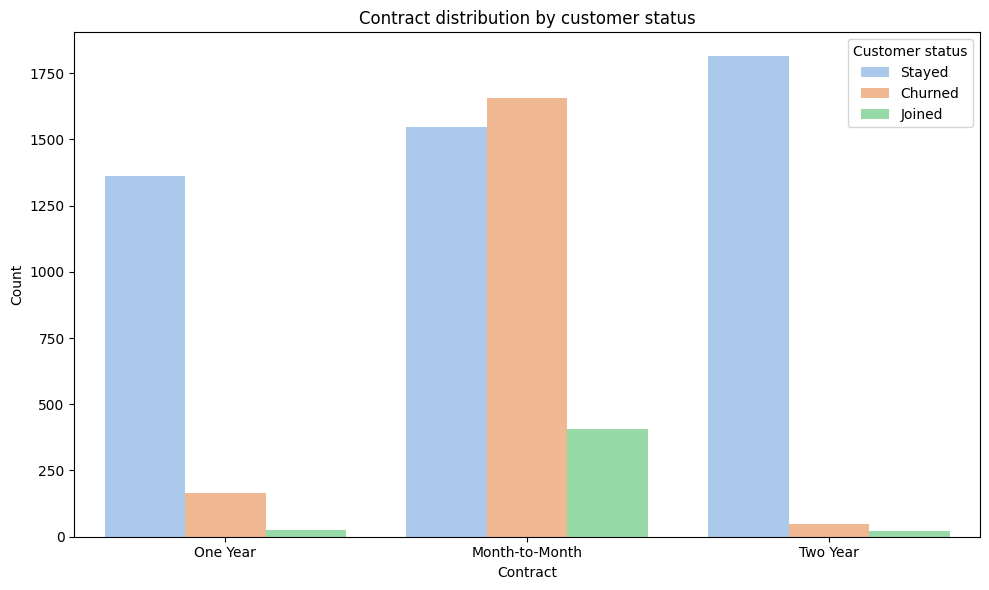

In [ ]:
plt.figure(figsize=(10,6))
sbn.countplot(
    data=df,
    x='contract',
    hue='customer_status'
)

plt.title('Contract distribution by customer status')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Customer status')
plt.tight_layout()
plt.show()

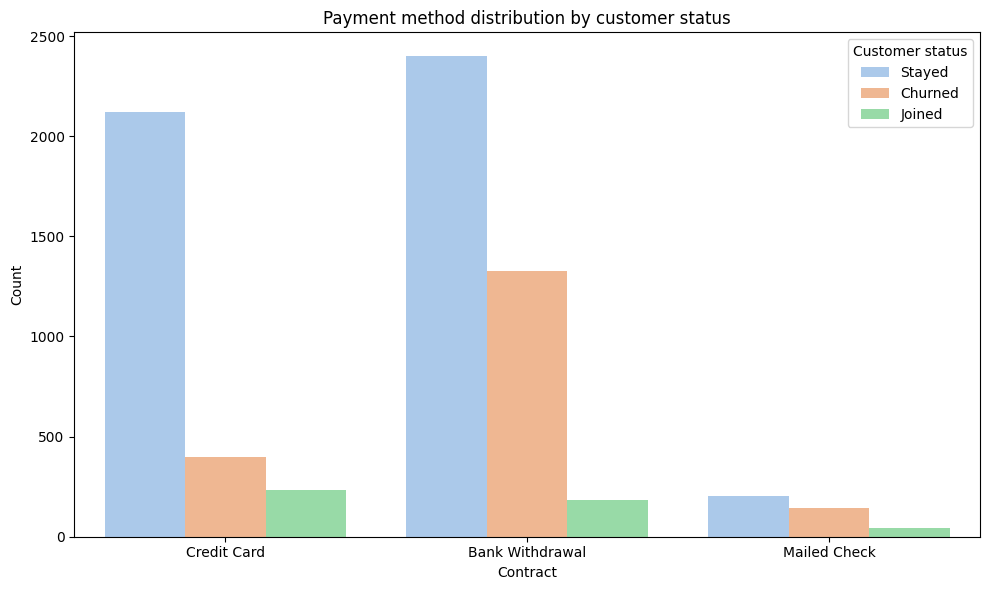

In [ ]:
plt.figure(figsize=(10,6))
sbn.countplot(
    data=df,
    x='payment_method',
    hue='customer_status'
)

plt.title('Payment method distribution by customer status')
plt.xlabel('Contract')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Customer status')
plt.tight_layout()
plt.show()

In [ ]:
pip install pywaffle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.6/25.6 MB 74.7 MB/s eta 0:00:00


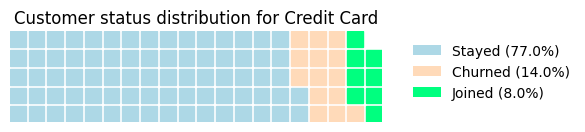

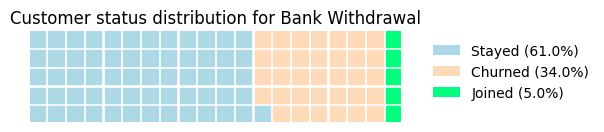

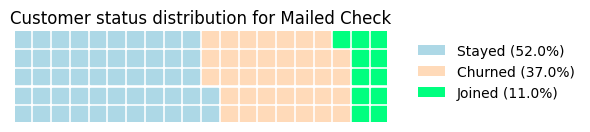

In [ ]:
from matplotlib.patches import Patch
from pywaffle import Waffle

methods = df['payment_method'].unique()
colors = ["lightblue", "peachpuff", "springgreen"]

for method in methods:
    subset = df[df['payment_method'] == method]
    status_counts = subset['customer_status'].value_counts()
    total = status_counts.sum()
    percent = (status_counts / total * 100).round()

    fig = plt.figure(
        FigureClass=Waffle,
        rows=5,
        values=percent,
        colors=colors,
        figsize=(6,4)
    )

    legend_elements = [
        Patch(facecolor=colors[i], label=f"{percent.index[i]} ({percent[i]}%)")
        for i in range(len(percent))
    ]

    plt.legend(
        handles=legend_elements,
        loc='upper left',
        bbox_to_anchor=(1.05, 1),
        frameon=False
    )

    plt.title(f'Customer status distribution for {method}')
    plt.tight_layout()
    plt.show()

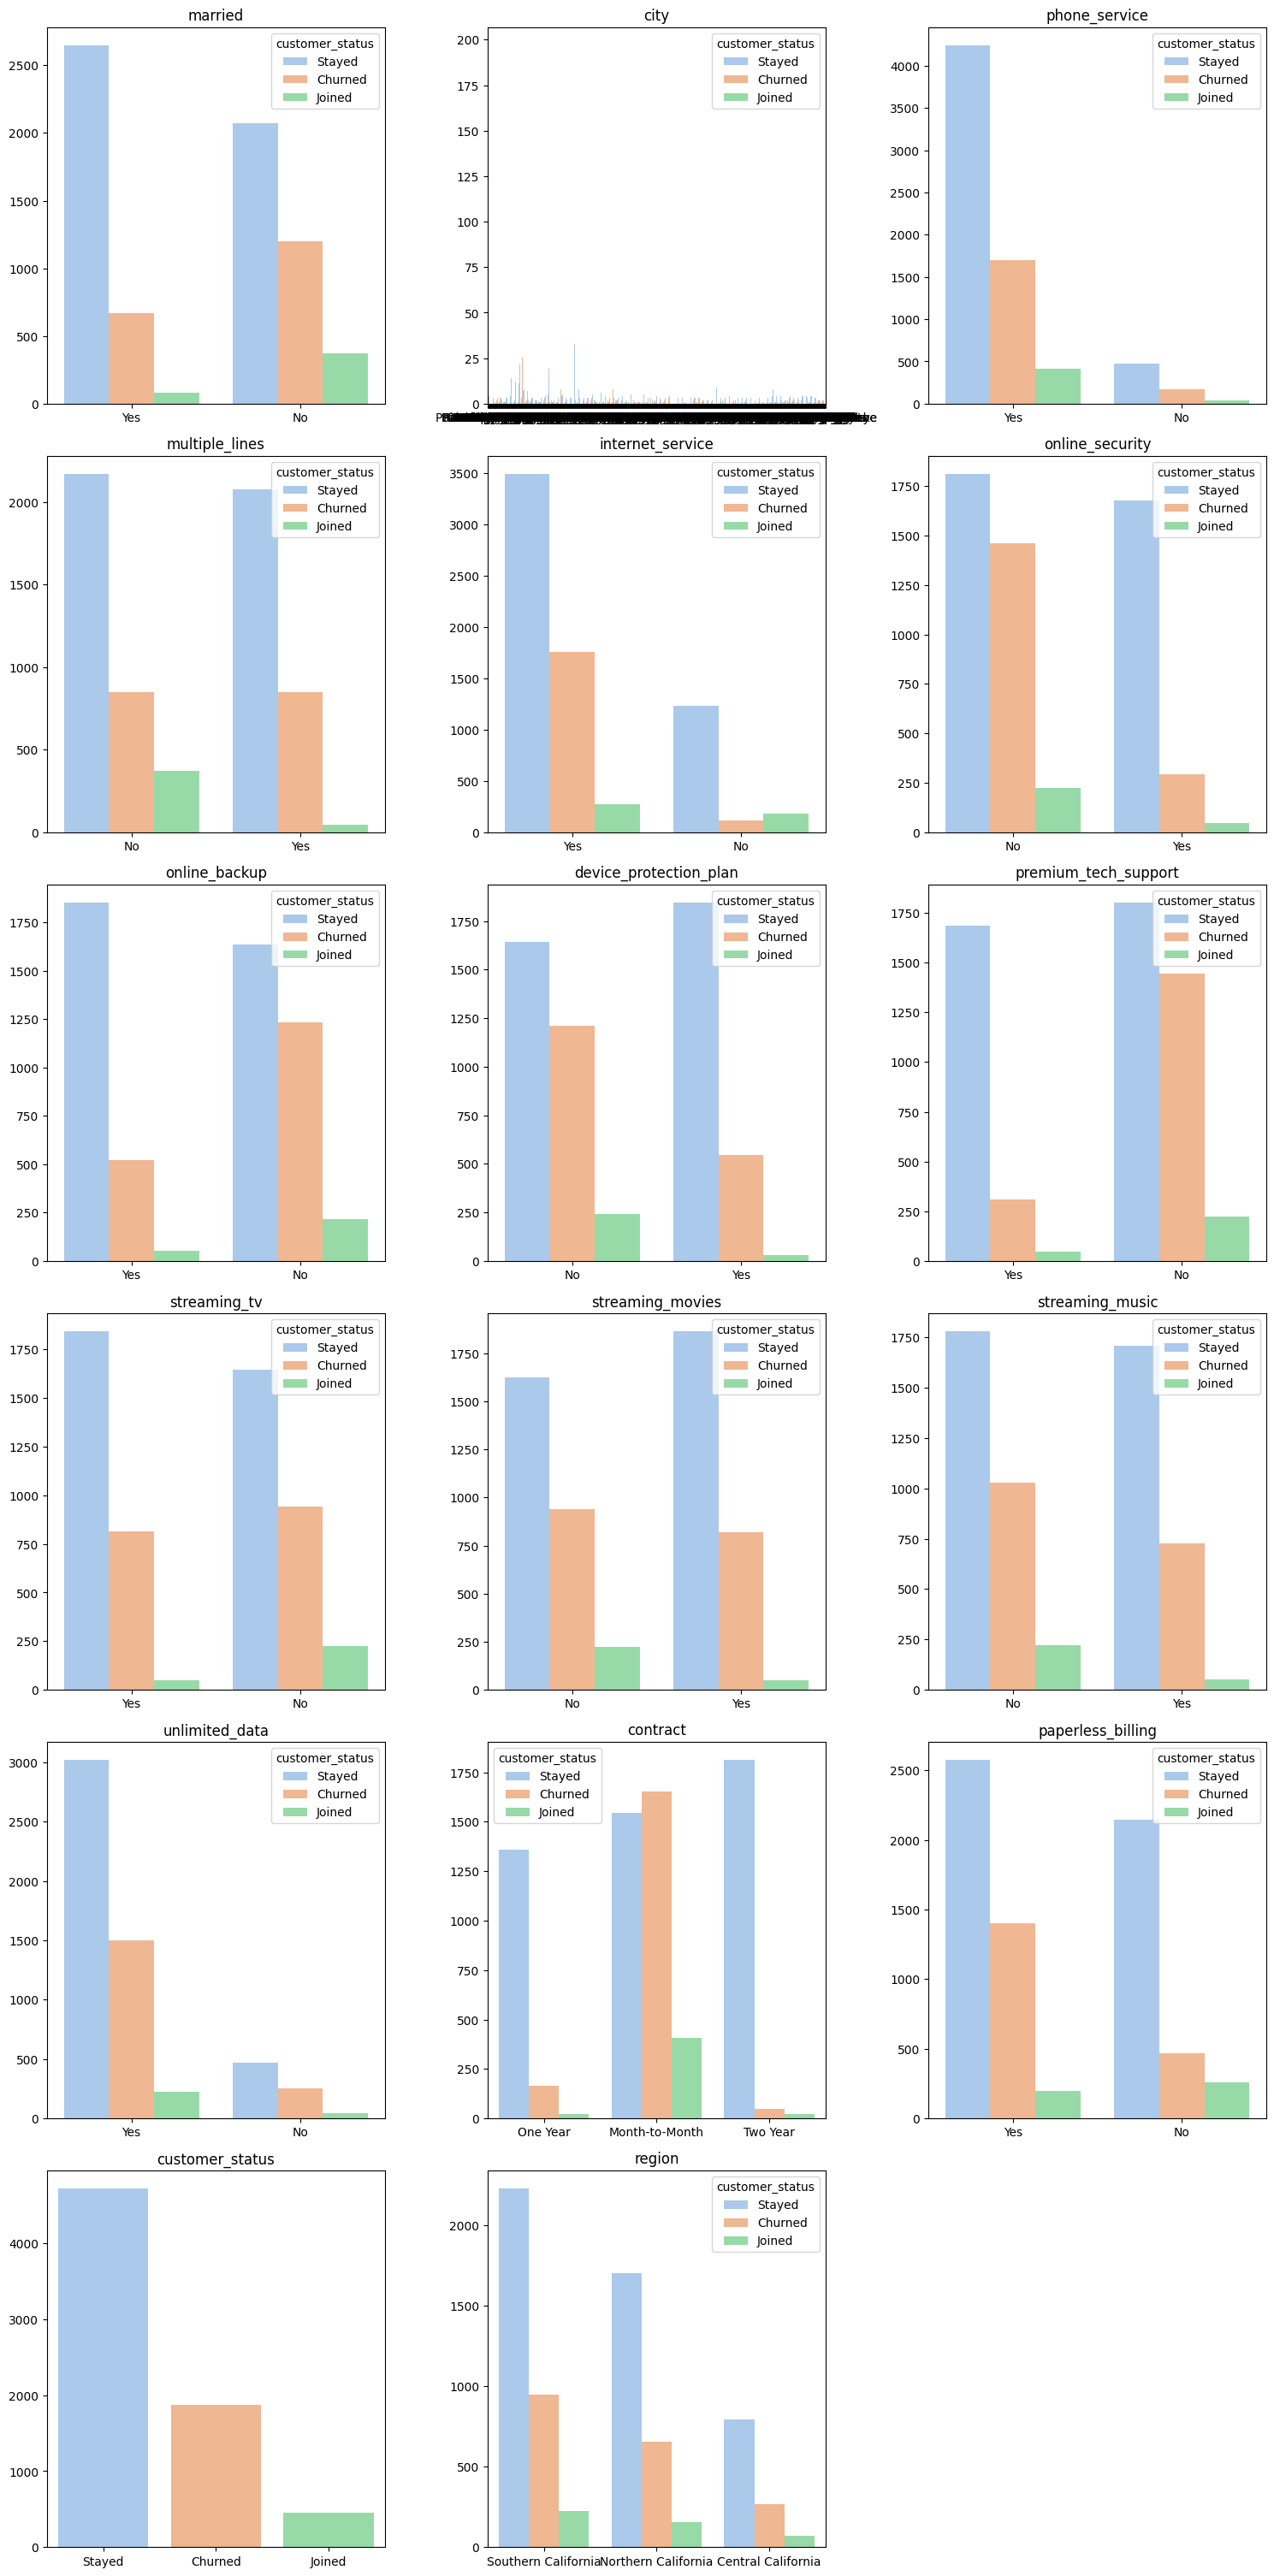

In [ ]:
n = len(categorical_cols)
rows = math.ceil(n / 3)
cols = 3

cat = df[categorical_cols].drop(columns=['gender','internet_type','offer', 'payment_method', 'churn_reason', 'churn_category'])

plt.figure(figsize=(15, 5*rows))
for i, col in enumerate(cat):
    plt.subplot(rows, cols, i+1)
    ax = sbn.countplot(
        data=cat,
        x = col,
        hue='customer_status'
    )

    ax.set(xlabel=None, ylabel=None)
    plt.title(str(col), loc='center')
    plt.xticks(fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
count = df['churn_reason'].value_counts()
count = count.sort_values(ascending=True)

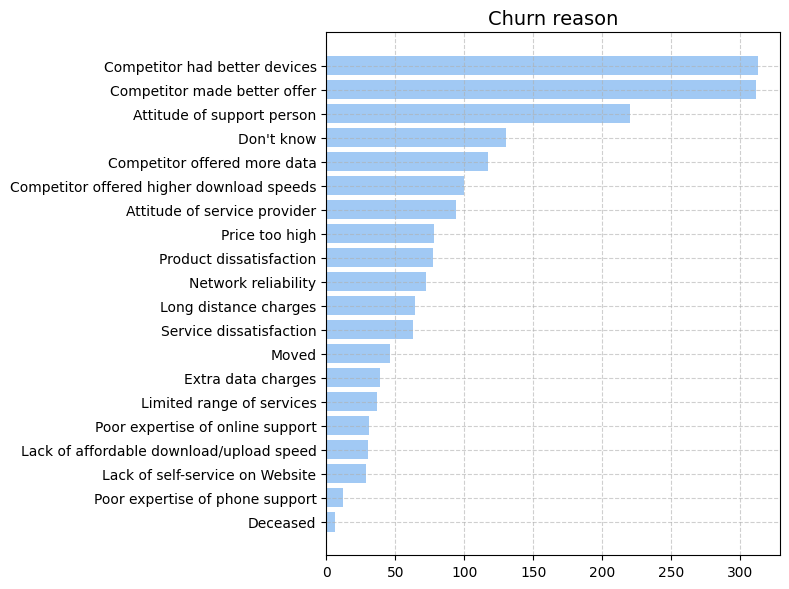

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(count.index, count.values)
plt.title('Churn reason', fontsize=14)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
count_2 = df['churn_category'].value_counts()
count_2 = count_2.sort_values(ascending=True)

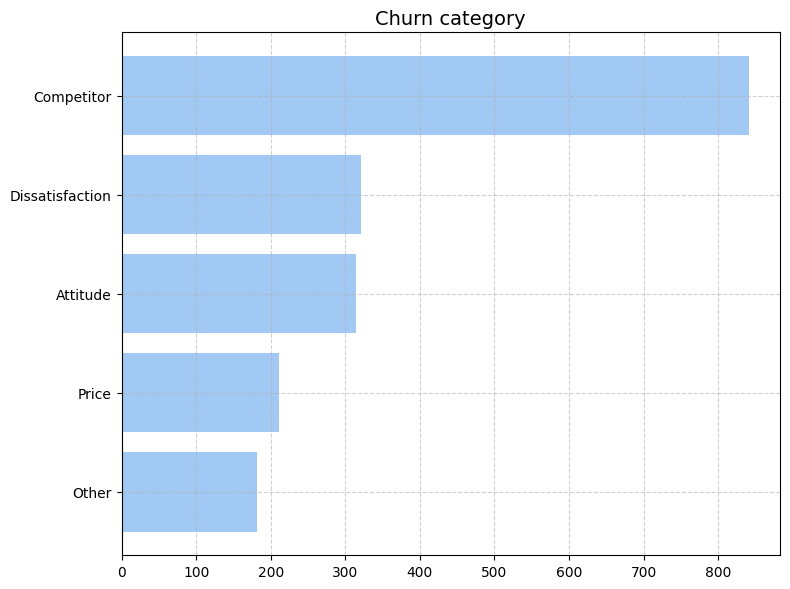

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(count_2.index, count_2.values)
plt.title('Churn category', fontsize=14)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
count_city = df['city'].value_counts()
top_majors = count_city.nlargest(6)
top_majors = top_majors.sort_values(ascending=False)

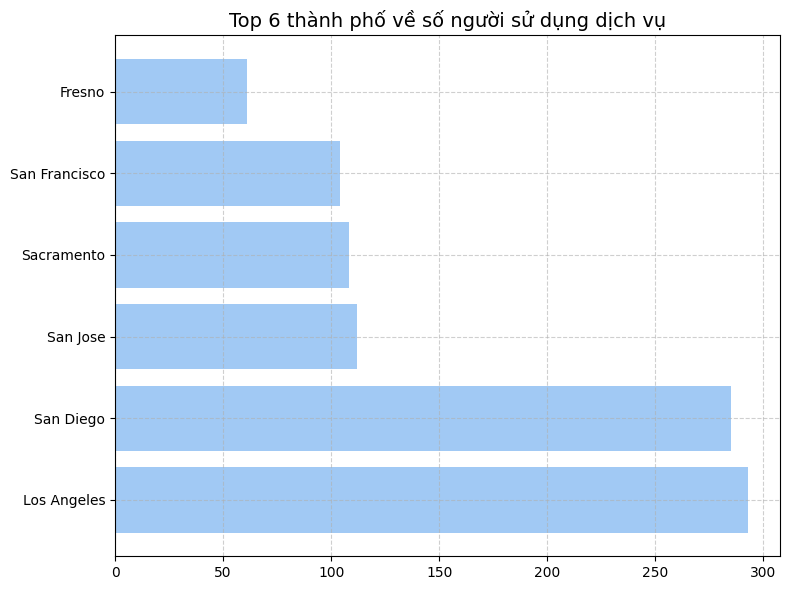

In [ ]:
plt.figure(figsize=(8, 6))
plt.barh(top_majors.index, top_majors.values)
plt.title('Top 6 thành phố về số người sử dụng dịch vụ', fontsize=14)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = df[numerical_cols].corr()
corr_matrix

,age,number_of_dependents,zip_code,latitude,longitude,number_of_referrals,tenure_in_months,avg_monthly_long_distance_charges,avg_monthly_gb_download,monthly_charge,total_charges,total_refunds,total_extra_data_charges,total_long_distance_charges,total_revenue
age,1.000000,-0.119000,-0.008183,-0.010305,0.007612,-0.025141,0.009927,-0.020010,-0.566518,0.134511,0.059684,0.024168,0.025036,0.003065,0.048265
number_of_dependents,-0.119000,1.000000,0.016493,0.029081,-0.024271,0.278003,0.108237,-0.002898,0.300802,-0.125649,0.022535,0.014023,-0.014436,0.068966,0.038038
zip_code,-0.008183,0.016493,1.000000,0.894769,-0.790564,0.001463,0.007146,0.012298,-0.002859,-0.002517,0.001978,-0.003797,-0.014550,0.005063,0.002944
latitude,-0.010305,0.029081,0.894769,1.000000,-0.885979,0.018715,0.011963,0.014450,-0.013485,-0.021613,-0.002784,-0.009901,-0.013233,0.008029,0.000082
longitude,0.007612,-0.024271,-0.790564,-0.885979,1.000000,-0.009893,-0.009672,-0.015420,0.015195,0.021052,0.003811,-0.000597,0.010461,-0.006923,0.001062
number_of_referrals,-0.025141,0.278003,0.001463,0.018715,-0.009893,1.000000,0.326975,0.001800,0.080243,0.026301,0.250378,0.024756,0.000350,0.216190,0.261853
tenure_in_months,0.009927,0.108237,0.007146,0.011963,-0.009672,0.326975,1.000000,0.012713,0.038173,0.239065,0.826074,0.059021,0.082266,0.674149,0.853146
avg_monthly_long_distance_charges,-0.020010,-0.002898,0.012298,0.014450,-0.015420,0.001800,0.012713,1.000000,0.019047,0.019149,0.016946,-0.026072,0.021162,0.548759,0.173072
avg_monthly_gb_download,-0.566518,0.300802,-0.002859,-0.013485,0.015195,0.080243,0.038173,0.019047,1.000000,-0.017283,0.031957,-0.011000,0.015451,0.024101,0.031922
monthly_charge,0.134511,-0.125649,-0.002517,-0.021613,0.021052,0.026301,0.239065,0.019149,-0.017283,1.000000,0.622810,0.023963,0.121238,0.235685,0.563249


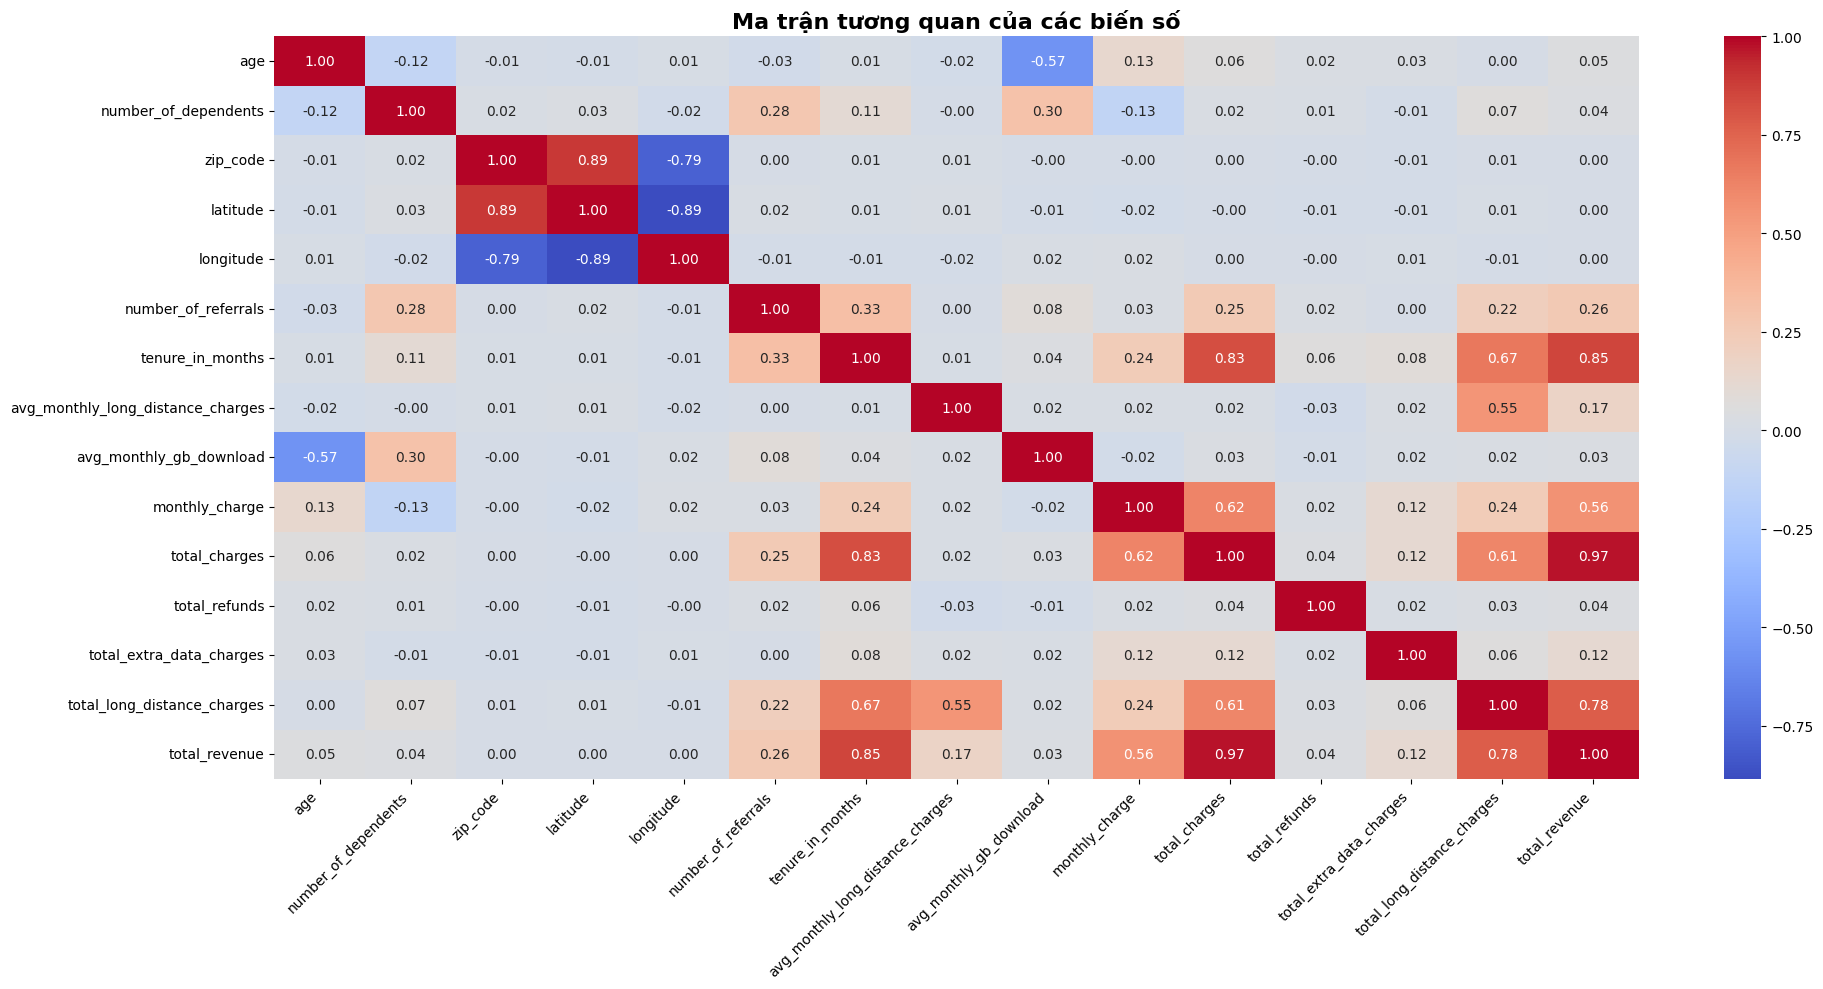

In [ ]:
plt.figure(figsize=(20, 10))
sbn.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Ma trận tương quan của các biến số", fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs.drop_duplicates().dropna()

high_corr = corr_pairs[corr_pairs > 0.5]
print(high_corr)


age                                age                            1.000000
zip_code                           latitude                       0.894769
tenure_in_months                   total_charges                  0.826074
                                   total_long_distance_charges    0.674149
                                   total_revenue                  0.853146
avg_monthly_long_distance_charges  total_long_distance_charges    0.548759
monthly_charge                     total_charges                  0.622810
                                   total_revenue                  0.563249
total_charges                      total_long_distance_charges    0.610185
                                   total_revenue                  0.972212
total_long_distance_charges        total_revenue                  0.778559
dtype: float64


In [ ]:
df.columns

Index(['gender', 'age', 'married', 'number_of_dependents', 'city', 'zip_code',
       'latitude', 'longitude', 'number_of_referrals', 'tenure_in_months',
       'offer', 'phone_service', 'avg_monthly_long_distance_charges',
       'multiple_lines', 'internet_service', 'internet_type',
       'avg_monthly_gb_download', 'online_security', 'online_backup',
       'device_protection_plan', 'premium_tech_support', 'streaming_tv',
       'streaming_movies', 'streaming_music', 'unlimited_data', 'contract',
       'paperless_billing', 'payment_method', 'monthly_charge',
       'total_charges', 'total_refunds', 'total_extra_data_charges',
       'total_long_distance_charges', 'total_revenue', 'customer_status',
       'churn_category', 'churn_reason', 'region'],
      dtype='object')